In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ModuleNotFoundError: No module named 'numpy'

In [ ]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt
#loading files
elevator_music="/kaggle/input/sample-audio/elevator-music-bossa-nova-background-music-version-60s-10900.mp3"
rock_music="/kaggle/input/sample-audio/energetic-rock-music-413285.mp3"
orchestra_music="/kaggle/input/sample-audio/honor-and-sword-main-11222.mp3"

In [ ]:
ipd.Audio(rock_music)

ValueError: rate must be specified when data is a numpy array or list of audio samples.

In [ ]:
ipd.Audio(orchestra_music)

In [ ]:
ipd.Audio(elevator_music)

In [ ]:
rock,sr=librosa.load(rock_music)
orchestra,sr_o=librosa.load(orchestra_music)
elevator,_=librosa.load(elevator_music)
rock
rock.size

In [ ]:
duration=1/sr
print(f"sample duration : {duration:.6f}")

In [ ]:
song_duration=duration*len(rock)
print(f"duration of song in  {song_duration: .3f}")

In [ ]:
#visualise waveforms
plt.figure(figsize=(15,20),alpha=0.5)
plt.subplot(3,1,1)
librosa.display.waveshow(rock,alpha=0.5)
plt.title("Rock")
plt.ylim((-1,1))

plt.subplot(3,1,2)
librosa.display.waveshow(orchestra,alpha=0.5)
plt.title("Orchestra")
plt.ylim((-1,1))


plt.subplot(3,1,3)
librosa.display.waveshow(elevator,alpha=0.5)
plt.title("Elevator")
plt.ylim((-1,1))
plt.show()


In [ ]:
def plot_magnitude_spectrum(signal,title,sr,f_ratio=0.05):
    ft=np.fft.fft(signal)
    #ft is complex no. so we will take onl magnitude
    # as magnitude represents amplitude and
    # we dont care about phase
    magnitude_spectrum=np.abs(ft)
    

    #plot magnitude_spectrum
    frequency=np.linspace(0,sr,len(magnitude_spectrum))
    num_freq_bins=int(len(frequency)*f_ratio)
    plt.plot(frequency[:num_freq_bins],magnitude_spectrum[:num_freq_bins])
    plt.xlabel("frequency")
    plt.title(title)
    plt.show()

In [ ]:
plot_magnitude_spectrum(rock,"Rock",sr)

# Exrtracting STFT


In [ ]:
FRAME_SIZE=2048
HOP_SIZE=512

In [ ]:
S_orchestra=librosa.stft(orchestra,n_fft=FRAME_SIZE,hop_length=HOP_SIZE)
# the output is a matrix

In [ ]:
S_orchestra.shape

# Calculating the spectrogram

In [ ]:
#take the squared magnitude of the output array

Y_orchestra=np.abs(S_orchestra)**2

In [ ]:
Y_orchestra.shape

# Visualizing the spectrogram

In [ ]:
def plotSpectrogram(Y,sr,hop_length,y_axis="linear"):
    plt.figure(figsize=(25,20))
    librosa.display.specshow(Y,
                    sr=sr,
                    hop_length=hop_length,
                    x_axis="time",
                    y_axis=y_axis)
    plt.colorbar(format="%2.f")

In [ ]:
plotSpectrogram(Y_orchestra,sr,HOP_SIZE)

# Log amplitude spectrogram

In [ ]:
Y_log_orchestra=librosa.power_to_db(Y_orchestra)
plotSpectrogram(Y_log_orchestra,sr,HOP_SIZE)

In [ ]:
plotSpectrogram(Y_log_orchestra,sr,HOP_SIZE,"log")

# Extracting MFCCs

In [ ]:
orchestra.shape

In [ ]:
mfccs=librosa.feature.mfcc(y=orchestra,n_mfcc=20,sr=sr_o)

In [ ]:
mfccs.shape

In [ ]:
#visualize mfccs
plt.figure(figsize=(25,10))
librosa.display.specshow(mfccs,
                        x_axis="time",
                        sr=sr_o)
plt.colorbar(format="%+2f")
plt.show()

In [ ]:
#calculate delta and delta2 mfcc
delta=librosa.feature.delta(mfccs)
delta2=librosa.feature.delta(mfccs,order=2)

In [ ]:
delta.shape

In [ ]:
plt.figure(figsize=(25,10))
librosa.display.specshow(delta,
                        x_axis="time",
                        sr=sr_o)
plt.colorbar(format="%+3f")
plt.show()

In [ ]:
plt.figure(figsize=(25,10))
librosa.display.specshow(delta2,
                        x_axis="time",
                        sr=sr_o)
plt.colorbar(format="%+3f")
plt.show()

In [ ]:
comprehensive_mfcc#comprehensive mfccs
comprehensive_mfcc=np.concatenate((mfccs,delta,delta2))

In [ ]:
plt.figure(figsize=(25,10))
librosa.display.specshow(comprehensive_mfcc,
                        x_axis="time",
                        sr=sr_o)
plt.colorbar(format="%+3f")
plt.show()

In [ ]:
comprehensive_mfcc.shape

In [ ]:
ipd.Audio("/kaggle/input/sample-wav-audio-files/Circle_of_fifths_chord_progression_-_minor.wav")


In [ ]:
ipd.Audio("/kaggle/input/sample-wav-audio-files/Beethoven_Diabelli_Variation_No._13.wav")


In [ ]:
moz_aud=ipd.Audio("/kaggle/input/sample-wav-audio-files/Mozart_from_Piano_Sonata_K310_first_movement.wav")


# Loading WAV files

In [ ]:
ckl_v,sr1=librosa.load("/home/raghav/Desktop/practice_code/MelodyTranscriber/data/samples/archive/Circle_of_fifths_chord_progression_-_minor.wav")
beethoven,sr2=librosa.load("/home/raghav/Desktop/practice_code/MelodyTranscriber/data/samples/archive/Beethoven_Diabelli_Variation_No._13.wav")
mozart,s3=librosa.load("/home/raghav/Desktop/practice_code/MelodyTranscriber/data/samples/archive/Mozart_from_Piano_Sonata_K310_first_movement.wav")
BAK,sr4=librosa.load("/home/raghav/Desktop/practice_code/MelodyTranscriber/data/samples/archive/BAK.wav")
rythm,sr5=librosa.load("/home/raghav/Desktop/practice_code/MelodyTranscriber/data/samples/archive/Divisive_rhythm_in_4-4_time.wav")

In [ ]:
# stft extraction
s_mozart=librosa.stft(mozart)

In [ ]:
s_mozart.shape

(1025, 557)

In [ ]:
#take the squared magnitude
y_mozart=np.abs(s_mozart)**2
y_mozart.shape

(1025, 557)

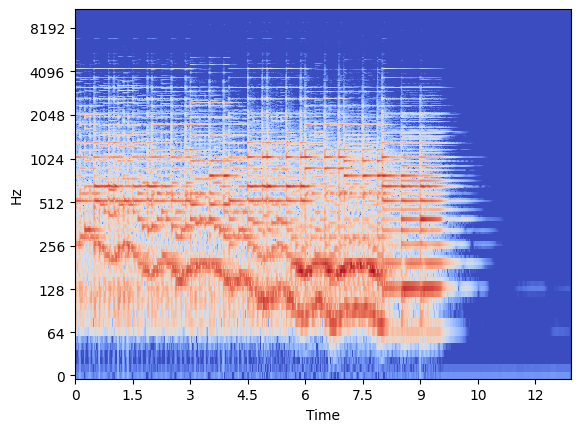

In [ ]:
D=librosa.power_to_db(y_mozart)
librosa.display.specshow(D,y_axis="log",x_axis="time")


# Basic pitch detection

In [ ]:
pitches,magnitudes=librosa.piptrack(S=s_mozart,sr=s3)

In [ ]:
print(pitches.shape)
print(magnitudes.shape)

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

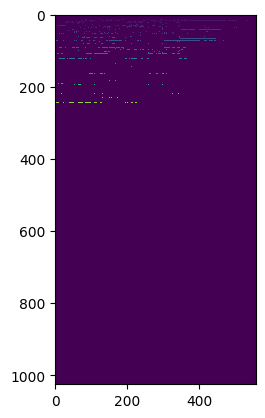

<Figure size 800x500 with 0 Axes>

In [ ]:
plt.imshow(pitches,cmap='viridis',interpolation='none')
plt.figure(figsize=(8,5))
plt.colorbar(label='value')
plt.xlabel("column")
plt.ylabel("row")
plt.show()
plt.plot(data_2d.T) # Matplotlib plots each column of the transposed array (original rows) as a line

plt.xlabel("X-axis values")
plt.ylabel("Y-axis values")
plt.title("Line Graph of a 2D Array (Transposed Method)")
plt.grid(True)
plt.show()

NameError: name 'sr' is not defined

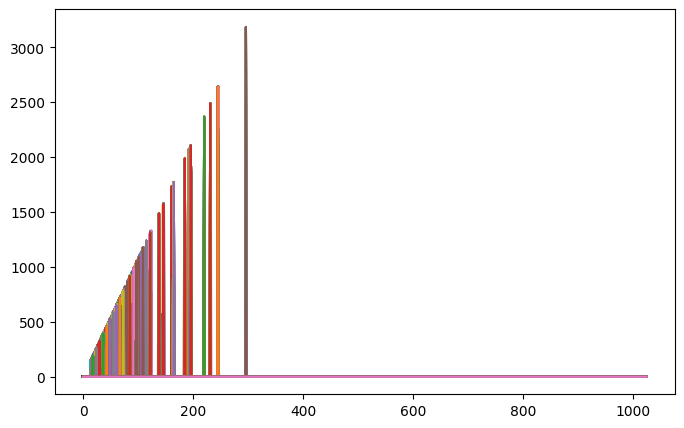

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(pitches)# After your piptrack call:
pitches, magnitudes = librosa.piptrack(y_mozart, sr=sr)

# Visualize 1: PITCH HEATMAP (like your spectrogram but for pitches only)
plt.figure(figsize=(12, 4))
librosa.display.specshow(pitches, 
                        y_axis='log', 
                        x_axis='time',
                        sr=sr, 
                        fmin=50, 
                        fmax=1000)
plt.title('Piptrack: Pitch Candidates (bright = detected)')
plt.colorbar(format='%+2.0f Hz')
plt.tight_layout()
plt.show()
 # Matplotlib plots each column of the transposed array (original rows) as a line

plt.xlabel("X-axis values")
plt.ylabel("Y-axis values")
plt.title("Line Graph of a 2D Array (Transposed Method)")
plt.grid(True)
plt.show()

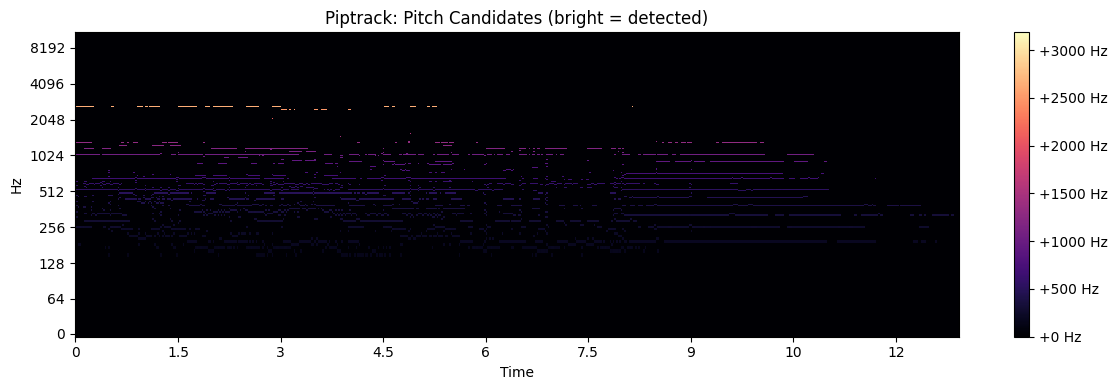

In [ ]:


# Visualize 1: PITCH HEATMAP (like your spectrogram but for pitches only)
plt.figure(figsize=(12, 4))
librosa.display.specshow(pitches, 
                        y_axis='log', 
                        x_axis='time',
                        sr=s3, 
                        fmin=50, 
                        fmax=1000)
plt.title('Piptrack: Pitch Candidates (bright = detected)')
plt.colorbar(format='%+2.0f Hz')
plt.tight_layout()
plt.show()


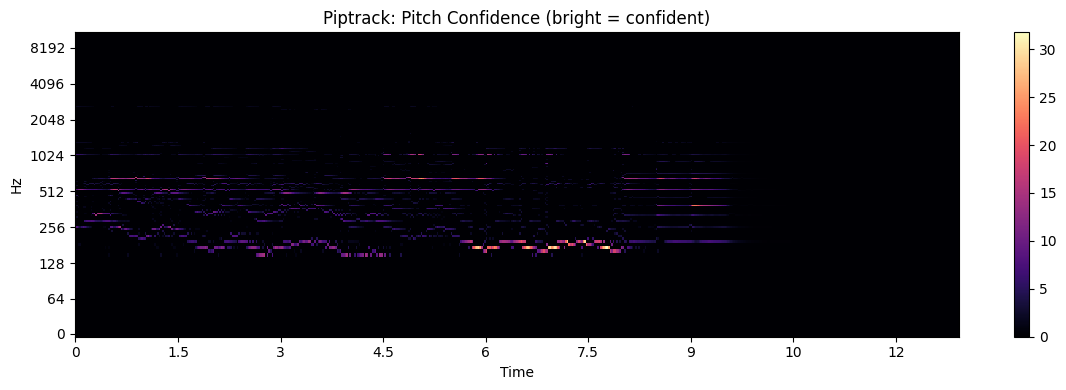

In [ ]:
# Visualize 2: MAGNITUDE HEATMAP (shows "confidence" of each pitch)
plt.figure(figsize=(12, 4))
librosa.display.specshow(magnitudes, 
                        y_axis='log', 
                        x_axis='time',
                        sr=s3, 
                        fmin=50, 
                        fmax=1000)
plt.title('Piptrack: Pitch Confidence (bright = confident)')
plt.colorbar()
plt.tight_layout()
plt.show()


In [ ]:
# simple pitch detection
pitch_values = []
for t in range(pitches.shape[1]):
    index = magnitudes[:, t].argmax()
    pitch_hz = pitches[index, t]
    if pitch_hz > 0:
        pitch_values.append(pitch_hz)

print("Detected pitches (Hz):", pitch_values[:20])
print("Note: Those yellow streaks in your spectrogram = these numbers")

Detected pitches (Hz): [np.float32(256.0724), np.float32(524.5973), np.float32(524.6796), np.float32(524.25757), np.float32(524.28613), np.float32(523.43585), np.float32(524.4387), np.float32(523.98834), np.float32(524.60345), np.float32(523.8972), np.float32(292.11215), np.float32(332.6376), np.float32(329.82715), np.float32(328.102), np.float32(330.37656), np.float32(331.48682), np.float32(330.91174), np.float32(329.6055), np.float32(329.35556), np.float32(330.11975)]
Note: Those yellow streaks in your spectrogram = these numbers


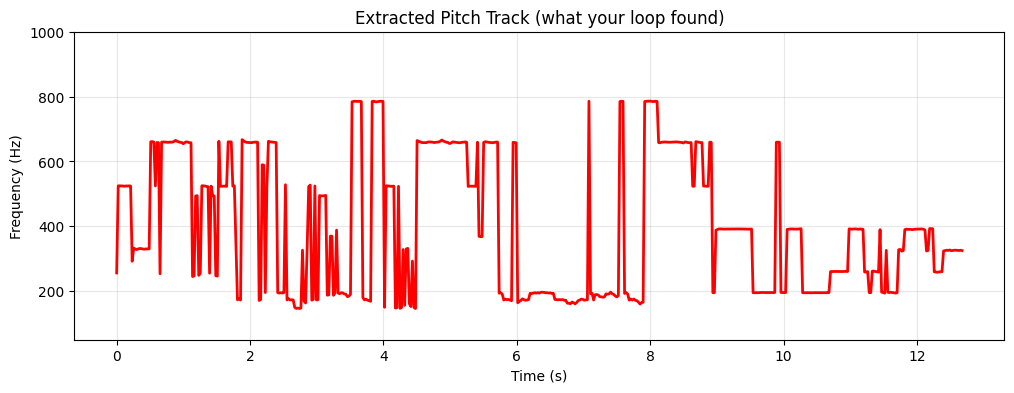

In [ ]:
# Visualize 3: YOUR PITCH TRACK (the final extracted pitches)
times = librosa.frames_to_time(np.arange(len(pitch_values)), sr=s3)
plt.figure(figsize=(12, 4))
plt.plot(times, pitch_values, linewidth=2, color='red')
plt.title('Extracted Pitch Track (what your loop found)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.grid(True, alpha=0.3)
plt.ylim(50, 1000)
plt.show()


In [ ]:
moz_aud